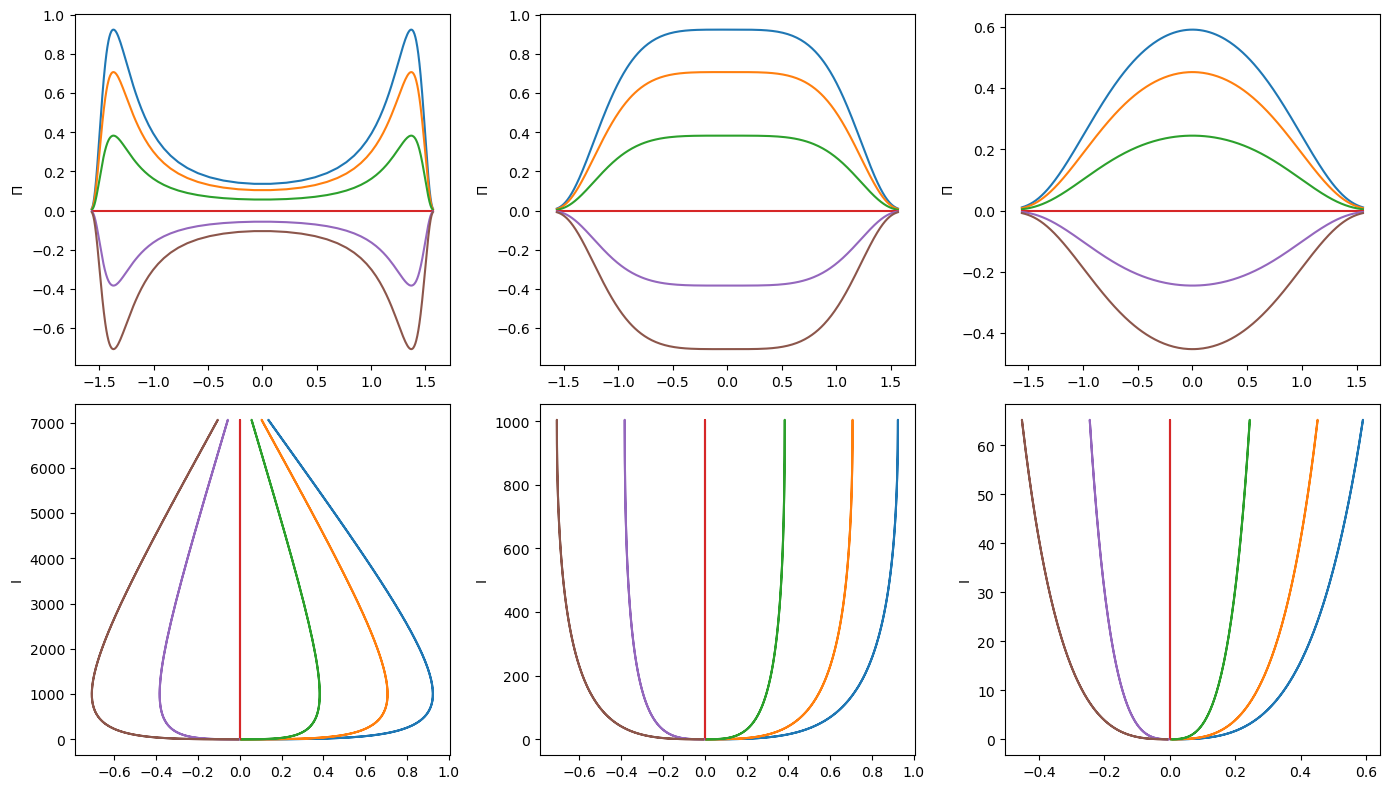

In [1]:
import numpy as np
import matplotlib.pyplot as plt

gamma=10.
beta=np.sqrt(1-1/gamma**2)

theta0_values=[
1/(5*gamma),
1/gamma,
2/gamma
]

pitch_angles=[
np.pi/16,
np.pi/8,
3*np.pi/16,
np.pi/4,
5*np.pi/16,
3*np.pi/8
]

phi=np.linspace(-1.5,1.5,1000)


def theta_obs(phi,theta0):

    return np.arccos(
        np.clip(
        np.cos(theta0)*
        np.cos(phi),
        -1,1
        )
    )


def PA(phi,theta0):

    x=np.sin(phi)/np.sqrt(
    1-
    np.cos(theta0)**2*
    np.cos(phi)**2
    )

    return np.arcsin(
    np.clip(x,-1,1)
    )


def jet_polarization(theta,psi):

    cos_thp=(
    np.cos(theta)-beta
    )/(
    1-beta*np.cos(theta)
    )

    thp=np.arccos(
    np.clip(cos_thp,-1,1)
    )

    return np.cos(
    2*psi
    )*np.sin(thp)**2


def doppler(theta):

    return 1./(gamma*(1-beta*np.cos(theta)))

fig,ax=plt.subplots(
2,
3,
figsize=(14,8)
)

for j,theta0 in enumerate(
theta0_values
):

    theta=theta_obs(
    phi,
    theta0
    )

    D=doppler(theta)

    I=D**3

    for psi in pitch_angles:

        P=jet_polarization(
        theta,
        psi
        )

        pa=PA(phi,theta0)

        ax[0,j].plot(pa,P)

        ax[1,j].plot(P, I)

    ax[0,j].set_ylabel(r'$\Pi$')

    ax[1,j].set_ylabel('I')

plt.tight_layout()
plt.show()